# Esperimenti sul dataset con pazienti/malattie

## Il grafo è separato dai componenti di Protein, GO e Gene, togliendo anche gli Article
## Il grafo risultante è schematizzato così:

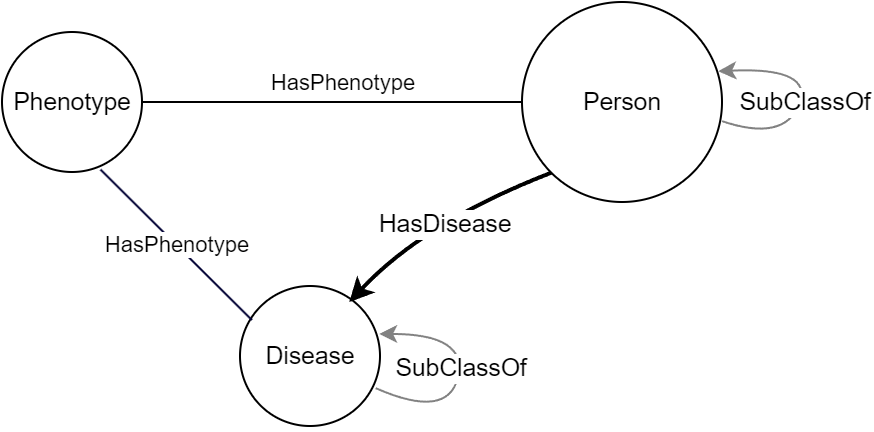

## Suddivisione train, val, test: 160'460, 16'301 e 778
### Sono incluse tutte le connessioni che coinvolgono le malattie associate ai pazienti e anche le loro malattie "parent"

## Test set creato esclusivamente sugli archi "Has disease"

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import math
from utilities import print_metricsKGE, print_times, stampa_tempi, carica_file, printBARS, printBARST
from sklearn.decomposition import PCA

stampa = False
data_dir = "mydir"

grid = ["l0.05|dim2", "l0.05|dim4", "l0.05|dim8", "l0.05|dim10", "l0.05|dim26", "l0.05|dim128"]

## Grid search esaustivo sugli iperparametri

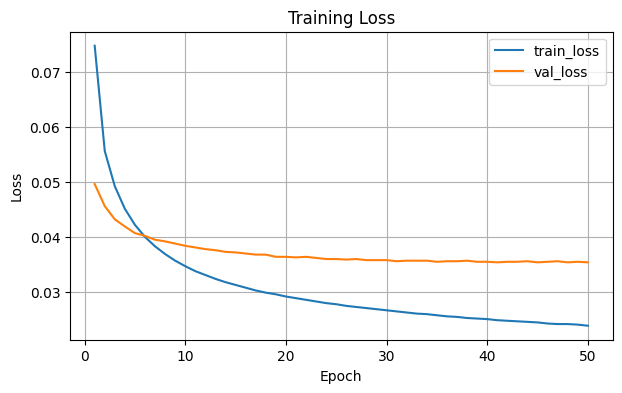

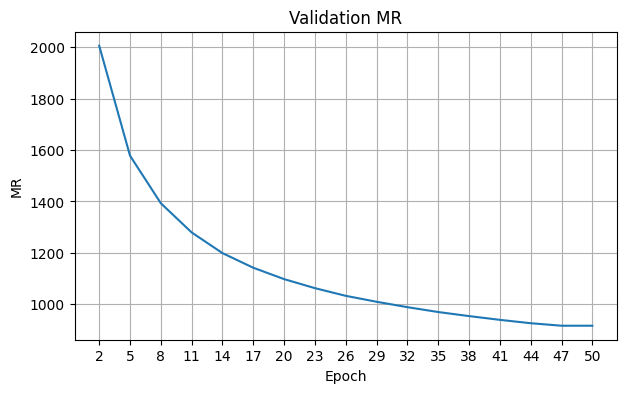

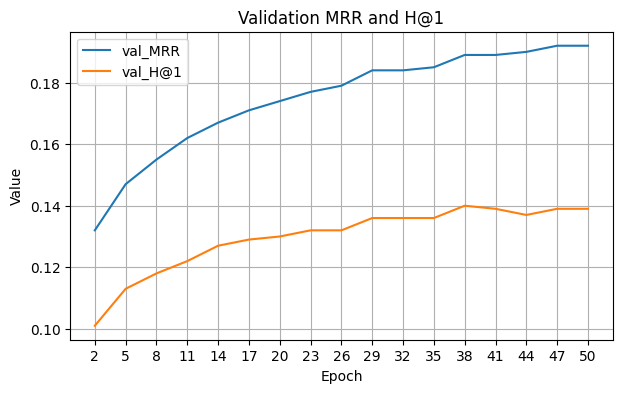

Test metrics finali:
  test_MR	= 115.91
  test_MRR	= 0.648
  test_H@1	= 0.584


In [ ]:
from utilities import caricaLogKGE

dataset = "Pazienti senza features KGEmb"
root_dir = data_dir+"/AttHN/26"

MRR, MR, H1, _, _, times = caricaLogKGE(root_dir, False, True)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utilities import caricaLogKGE

seeds = ["", "_2", "_3"]

data_dirs = [data_dir+"/AttHN/", data_dir+"/AttEN/"]
combinations = ["2", "4", "8", "10", "26", "128"]

MRRS = [[], []]
MRS =  [[], []]
H1S =  [[], []]
H3S =  [[], []]
H10S =  [[], []]
allT =  [[], []]
allTm =  [[], []]

for i in range(len(data_dirs)):
    root = data_dirs[i]
    for s in seeds:
        mrrs = []
        mrs = []
        h1s, h3s, h10s = [], [], []
        times = []
        times2 = []
        for j in combinations:
            p = root + j + str(s)

            mr, mrr, h1, h3, h10, time = caricaLogKGE(p)
            mrrs.append(mrr[0])
            mrs.append(mr[0])
            h1s.append(h1[0])
            h3s.append(h3[0])
            h10s.append(h10[0])
            times.append(np.sum(time))
            times2.append(np.mean(time))
        MRRS[i].append(mrrs)
        MRS[i].append(mrs)
        H1S[i].append(h1s)
        H3S[i].append(h3s)
        H10S[i].append(h10s)
        allT[i].append(times)
        allTm[i].append(times2)

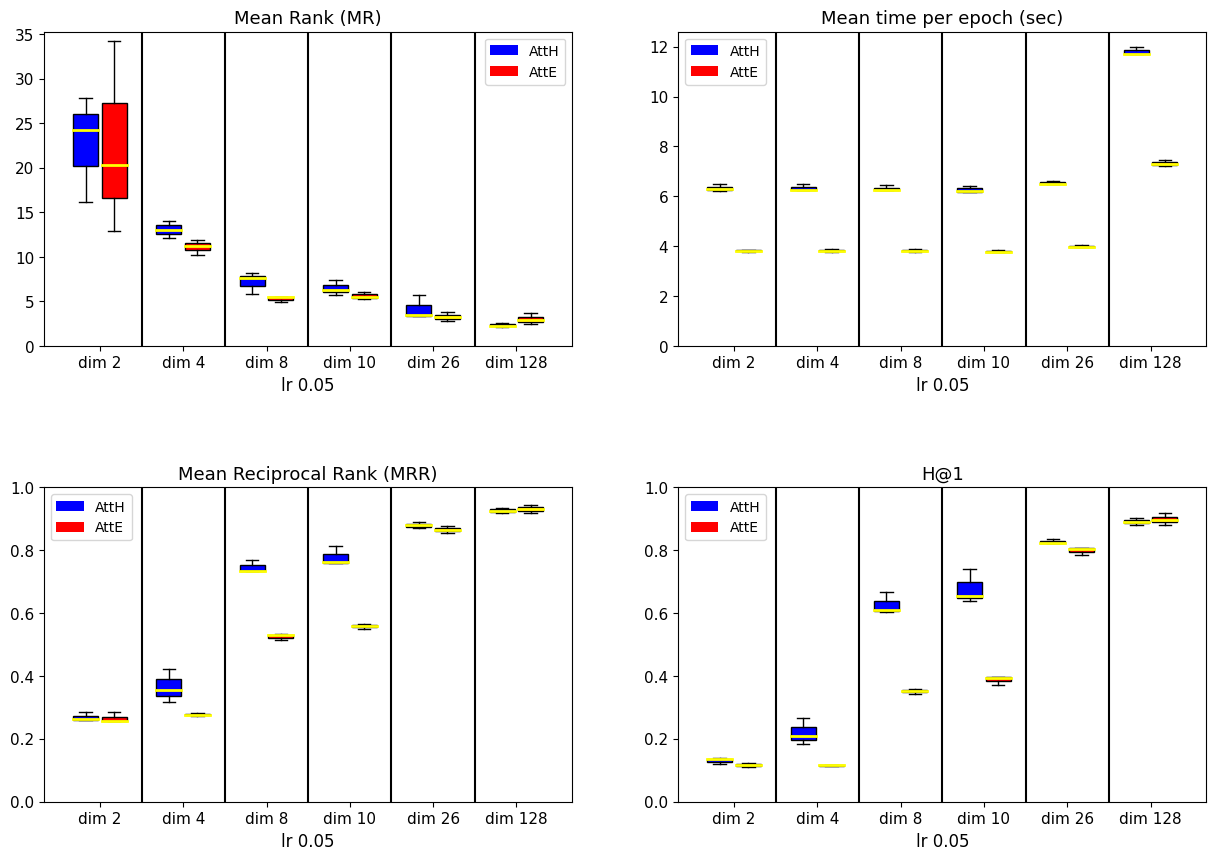

In [4]:
import matplotlib.pyplot as plt

grid = ["dim 2", "dim 4", "dim 8", "dim 10", "dim 26", "dim 128"]

pos = np.arange(len(grid))

wd = 0.3
a = wd*(4/7)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
boxmr, boxtime, boxmrr, boxh1 = [], [], [], []

for i in pos:
    boxmr.append(axs[0, 0].boxplot(np.array(MRS)[0][:, i], positions=[pos[i]-a], widths=wd, patch_artist=True))
    boxmr.append(axs[0, 0].boxplot(np.array(MRS)[1][:, i], positions=[pos[i]+a], widths=wd, patch_artist=True))
    
    boxtime.append(axs[0, 1].boxplot(np.array(allTm)[0][:, i], positions=[pos[i]-a], widths=wd, patch_artist=True))
    boxtime.append(axs[0, 1].boxplot(np.array(allTm)[1][:, i], positions=[pos[i]+a], widths=wd, patch_artist=True))
    
    boxmrr.append(axs[1, 0].boxplot(np.array(MRRS)[0][:, i], positions=[pos[i]-a], widths=wd, patch_artist=True))
    boxmrr.append(axs[1, 0].boxplot(np.array(MRRS)[1][:, i], positions=[pos[i]+a], widths=wd, patch_artist=True))
    
    boxh1.append(axs[1, 1].boxplot(np.array(H1S)[0][:, i], positions=[pos[i]-a], widths=wd, patch_artist=True))
    boxh1.append(axs[1, 1].boxplot(np.array(H1S)[1][:, i], positions=[pos[i]+a], widths=wd, patch_artist=True))
    
    if i!=0:
        axs[0, 0].axvline(i-0.5, color="black")
        axs[0, 1].axvline(i-0.5, color="black")
        axs[1, 0].axvline(i-0.5, color="black")
        axs[1, 1].axvline(i-0.5, color="black")

for i in range(2):
    for j in range(2):
        axs[i, j].bar(0, 0, color="blue", label="AttH")
        axs[i, j].bar(0, 0, color="red", label="AttE")

        axs[i, j].set_xticks(pos)
        axs[i, j].legend(loc='best')
        axs[i, j].tick_params(axis='y', labelsize=11)
        axs[i, j].set_xticklabels(grid, fontsize=11)
        axs[i, j].set_xlabel("lr 0.05", fontsize=12)
        
for boxes in [boxmr, boxtime, boxmrr, boxh1]:
    for i in range(len(boxes)):
        if i%2==0:
            boxes[i]['boxes'][0].set_facecolor('blue')
        else:
            boxes[i]['boxes'][0].set_facecolor('red')
        boxes[i]['medians'][0].set(color='yellow', linewidth=2)

            
axs[0, 0].set_title("Mean Rank (MR)", fontsize=13)
axs[0, 1].set_title("Mean time per epoch (sec)", fontsize=13)
axs[1, 0].set_title("Mean Reciprocal Rank (MRR)", fontsize=13)
axs[1, 1].set_title("H@1", fontsize=13)
axs[0, 0].set_ylim(0, np.max(MRS)+1)
axs[1, 0].set_ylim(0, 1)
axs[1, 1].set_ylim(0, 1)

fig.subplots_adjust(hspace=0.45)

plt.show()

# Confronto con i metodi HGCN e GCN

In [ ]:
import pandas as pd
import numpy as np
from utilities import print_times

mrrs = []
mrs = []
h1s = []
rnk = []
h3s = []
h10s = []

for model in ["hgcn", "gcn"]:
    for n in [55, 57, 59]:

        f = pd.read_csv(data_dir+"/../rsN" + str(n) + model + ".csv")

        pazienti = np.unique(f["patient"])

        test = pd.read_csv(data_dir+"/../disease_lp.edgesNoGF"+str(n)+".csv")
        test = test.rename(columns={"0": "subject", "1": "object"})

        pool = test[:780]
        
        f = pd.read_csv(data_dir+"/../rsN" + str(n) + model + ".csv")
        rank, irank = [], []
        for i in pazienti:
            # prendo la malattia vera associata al paziente
            j = pool[pool["subject"]==i]["object"].values.item()

            # vedo tutte le malattie ordinate per probabilità decrescente
            p = f[f["patient"]==i]
            p = p.sort_values(by="prob", ascending=False)
            p = p.reset_index()

            # lista ordinata delle malattie in ordine di probabilità decrescente
            res = list(p["disease"].values)
            
            idx = res.index(j)+1
            irank.append(1/idx)
            rank.append(idx)
        
        h10, h3 = 0, 0
        for i in rank:
            if i <= 3:
                h3 += 1
                h10 += 1
            elif i <=10:
                h10 += 1
        
        rnk.append(rank)
        mrs.append(np.mean(rank))
        mrrs.append(np.mean(irank))
        h1s.append(np.mean([1 if x == 1 else 0 for x in rank]))
        h3s.append(h3/len(rank))
        h10s.append(h10/len(rank))

In [8]:
times = []
# HGCN 11, 11, 11       GCN 11, 7, 11
hgcn = data_dir+"2026_1_20_gridHGCNnoGF55/11"
hgcn2 = data_dir+"2026_1_20_gridHGCNnoGF57/11"
hgcn3 = data_dir+"2026_1_20_gridHGCNnoGF59/11"
gcn = data_dir+"2026_1_20_gridGCNnoGF55/11"
gcn2 = data_dir+"2026_1_20_gridGCNnoGF57/7"
gcn3 = data_dir+"2026_1_20_gridGCNnoGF59/11"

times.append([np.sum(np.array(print_times(hgcn+"/log.txt", False)[0])*15), np.mean(print_times(hgcn+"/log.txt", False)[0])])
times.append([np.sum(np.array(print_times(hgcn2+"/log.txt", False)[0])*15), np.mean(print_times(hgcn2+"/log.txt", False)[0])])
times.append([np.sum(np.array(print_times(hgcn3+"/log.txt", False)[0])*15), np.mean(print_times(hgcn3+"/log.txt", False)[0])])
times.append([np.sum(np.array(print_times(gcn+"/log.txt", False)[0])*15), np.mean(print_times(gcn+"/log.txt", False)[0])])
times.append([np.sum(np.array(print_times(gcn2+"/log.txt", False)[0])*15), np.mean(print_times(gcn2+"/log.txt", False)[0])])
times.append([np.sum(np.array(print_times(gcn3+"/log.txt", False)[0])*15), np.mean(print_times(gcn3+"/log.txt", False)[0])])

## Confronto tra i migliori per categoria

In [9]:
hgcn = 'HGCN l0.09|dim26', 'HGCN l0.09|dim26_2', 'HGCN l0.09|dim26_3'
gcn = 'GCN l0.09|dim26', 'GCN l0.01|dim26_2', 'GCN l0.09|dim26_3'
atth = 4
atte = 4

all_mr = [mrs[:3], np.array(MRS)[0][:, atth], mrs[3:], np.array(MRS)[1][:, atte]]
all_time = [np.array(times)[:, 0][:3], np.array(allT)[0][:, atth], np.array(times)[:, 0][3:], np.array(allT)[1][:, atte]]
all_time2 = [np.array(times)[:, 1][:3], np.array(allTm)[0][:, atth], np.array(times)[:, 1][3:], np.array(allTm)[1][:, atte]]
all_mrr = [mrrs[:3], np.array(MRRS)[0][:, atth], mrrs[3:], np.array(MRRS)[1][:, atte]]
all_h1 = [h1s[:3], np.array(H1S)[0][:, atth], h1s[3:], np.array(H1S)[1][:, atte]]
all_h3= [h3s[:3], np.array(H3S)[0][:, atth], h3s[3:], np.array(H3S)[1][:, atte]]
all_h10= [h10s[:3], np.array(H10S)[0][:, atth], h10s[3:], np.array(H10S)[1][:, atte]]

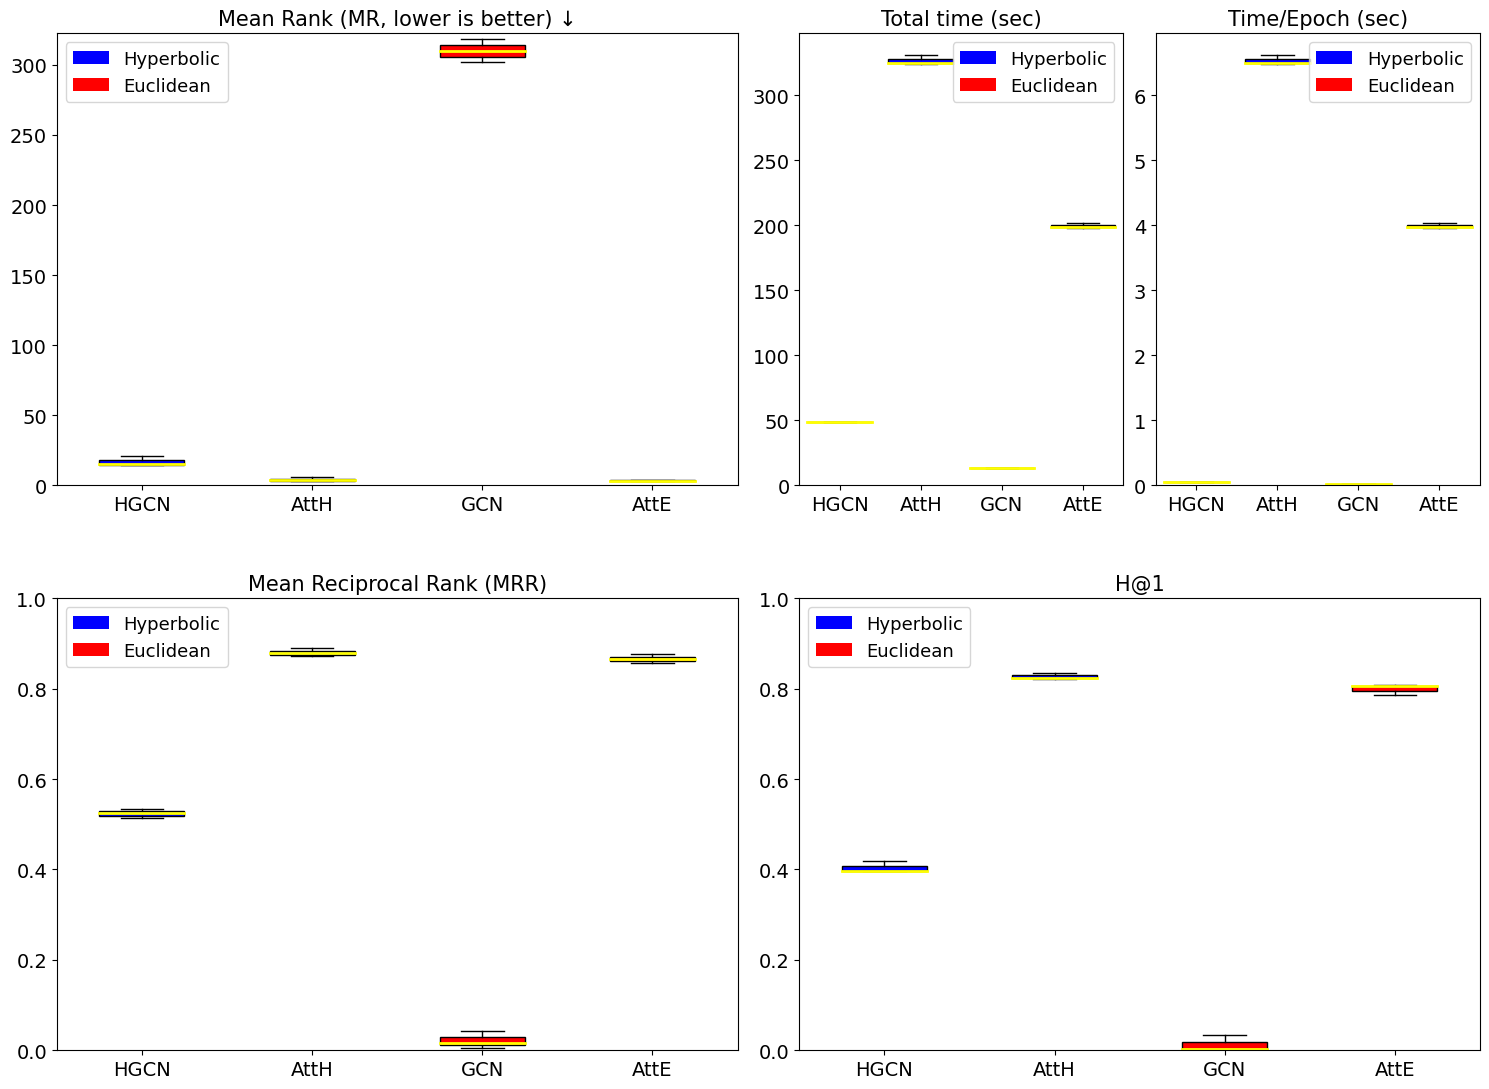

In [19]:
wd = 0.4
pps = [0, 1, 2, 3]
names = ["HGCN", "AttH", "GCN", "AttE"]

fig, axs = plt.subplots(2, 2, figsize=(15, 11))

axs[0,1].remove()
gs = fig.add_gridspec(2, 2)
subgs = gs[0,1].subgridspec(1, 2, wspace=0.1)

ax_time1 = fig.add_subplot(subgs[0])
ax_time2 = fig.add_subplot(subgs[1])

boxmr, boxmrr, boxh1 = [], [], []
boxtime1, boxtime2 = [], []

for i in range(len(pps)):
    boxmr.append(axs[0,0].boxplot(all_mr[i], positions=[pps[i]], widths=wd+0.1, patch_artist=True))
    boxtime1.append(ax_time1.boxplot(all_time[i], positions=[pps[i]], widths=wd*2, patch_artist=True))
    boxtime2.append(ax_time2.boxplot(all_time2[i], positions=[pps[i]], widths=wd*2, patch_artist=True))
    boxmrr.append(axs[1,0].boxplot(all_mrr[i], positions=[pps[i]], widths=wd+0.1, patch_artist=True))
    boxh1.append(axs[1,1].boxplot(all_h1[i], positions=[pps[i]], widths=wd+0.1, patch_artist=True))


# ticks e legenda
for ax in [axs[0, 0], axs[1, 0], axs[1, 1]]:
    ax.bar(0, 0, color="blue", label="Hyperbolic")
    ax.bar(0, 0, color="red", label="Euclidean")

    ax.set_xticks(pps)
    ax.set_xticklabels(names, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(loc="upper left", fontsize=13)
    ax.margins(x=0.01)

for ax in [ax_time1, ax_time2]:
    ax.bar(0, 0, color="blue", label="Hyperbolic")
    ax.bar(0, 0, color="red", label="Euclidean")

    ax.set_xticks(pps)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticklabels(names, fontsize=14)
    ax.legend(loc="upper right", fontsize=13)

def color_boxes(boxes):
    for i in range(len(boxes)):
        if i//2 == 0:
            boxes[i]['boxes'][0].set_facecolor('blue')
        else:
            boxes[i]['boxes'][0].set_facecolor('red')
        boxes[i]['medians'][0].set(color='yellow', linewidth=2)


for b in [boxmr, boxtime1, boxtime2, boxmrr, boxh1]:
    color_boxes(b)


axs[0, 0].set_title("Mean Rank (MR, lower is better) ↓", fontsize=15)
ax_time1.set_title("Total time (sec)", fontsize=15)
ax_time2.set_title("Time/Epoch (sec)", fontsize=15)
axs[1,0].set_title("Mean Reciprocal Rank (MRR)", fontsize=15)
axs[1,1].set_title("H@1", fontsize=15)

axs[0,0].set_ylim(0, np.max(all_mr)+4)
axs[1,0].set_ylim(0,1)
axs[1,1].set_ylim(0,1)
plt.tight_layout()

fig.subplots_adjust(hspace=0.25)
plt.show()

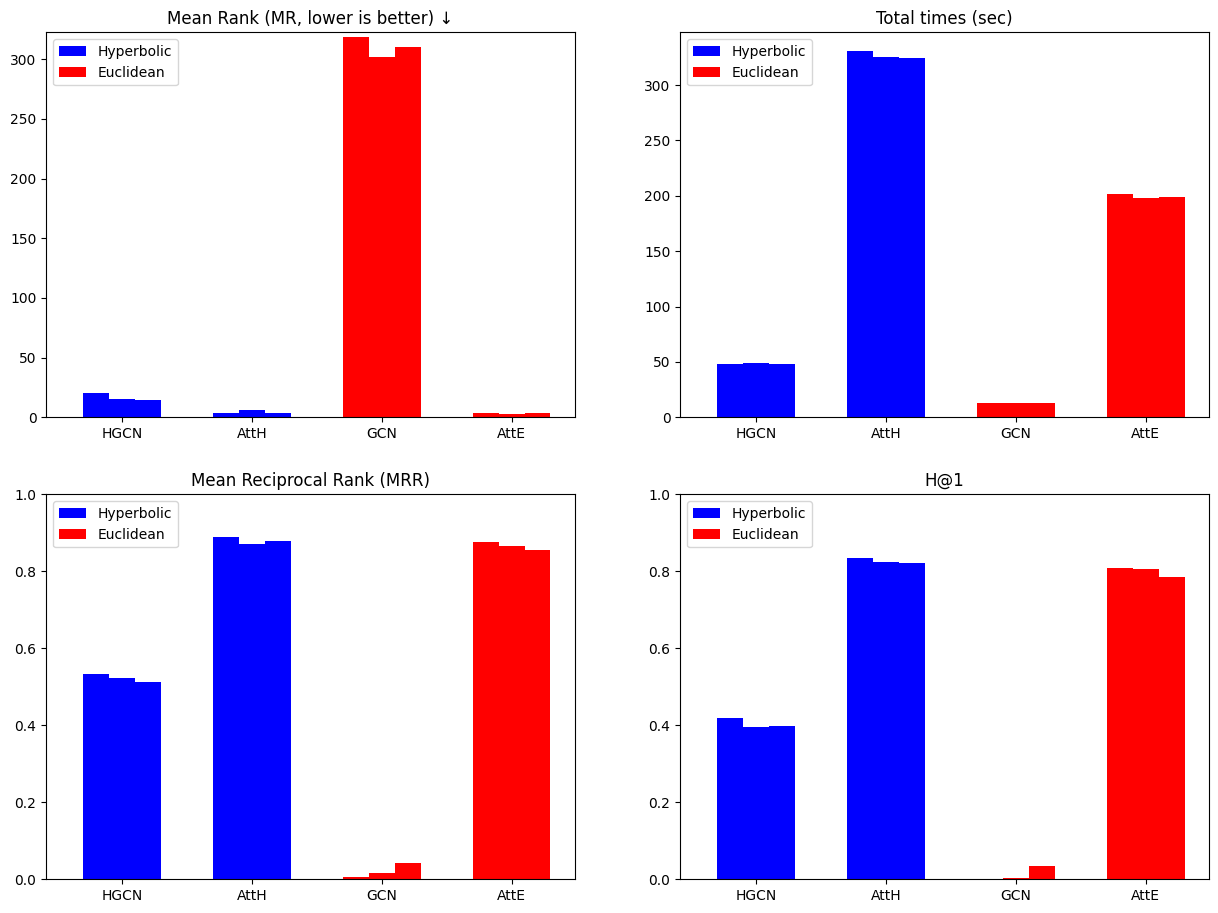

In [11]:
wd = 0.2
pps = []
for i in range(len(all_mr)):
    pps.append([(i-wd), i, i+wd])

pps = np.array([-wd, 0, wd])
names = ["HGCN", "AttH", "GCN", "AttE"]

fig, axs = plt.subplots(2, 2, figsize=(15, 11))

axs[0, 0].bar(pps, np.array(mrs)[:3], width=wd, color="blue")
axs[0, 0].bar(pps+1, np.array(MRS)[0][:, 4], width=wd, color="blue")
axs[0, 0].bar(pps+2, np.array(mrs)[3:], width=wd, color="red")
axs[0, 0].bar(pps+3, np.array(MRS)[1][:, 4], width=wd, color="red")

axs[0, 1].bar(pps, np.array(times)[:, 0][:3], width=wd, color="blue")
axs[0, 1].bar(pps+1, np.array(allT)[0][:, 4], width=wd, color="blue")
axs[0, 1].bar(pps+2, np.array(times)[:, 0][3:], width=wd, color="red")
axs[0, 1].bar(pps+3, np.array(allT)[1][:, 4], width=wd, color="red")

axs[1, 0].bar(pps, np.array(mrrs)[:3], width=wd, color="blue")
axs[1, 0].bar(pps+1, np.array(MRRS)[0][:, 4], width=wd, color="blue")
axs[1, 0].bar(pps+2, np.array(mrrs)[3:], width=wd, color="red")
axs[1, 0].bar(pps+3, np.array(MRRS)[1][:, 4], width=wd, color="red")

axs[1, 1].bar(pps, np.array(h1s)[:3], width=wd, color="blue")
axs[1, 1].bar(pps+1, np.array(H1S)[0][:, 4], width=wd, color="blue")
axs[1, 1].bar(pps+2, np.array(h1s)[3:], width=wd, color="red")
axs[1, 1].bar(pps+3, np.array(H1S)[1][:, 4], width=wd, color="red")

for i in range(2):
    for j in range(2):
        axs[i, j].bar(0, 0, color="blue", label="Hyperbolic")
        axs[i, j].bar(0, 0, color="red", label="Euclidean")

        axs[i, j].set_xticks([0, 1, 2, 3])
        axs[i, j].legend(loc='upper left')
        axs[i, j].set_xticklabels(names)

axs[0, 0].set_title("Mean Rank (MR, lower is better) ↓")
axs[0, 1].set_title("Total times (sec)")
axs[1, 0].set_title("Mean Reciprocal Rank (MRR)")
axs[1, 1].set_title("H@1")
axs[0, 0].set_ylim(0, np.max(all_mr)+4)
axs[1, 0].set_ylim(0, 1)
axs[1, 1].set_ylim(0, 1)

plt.show()